In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

## Semi-Analytical Solution for zero relaxation

In [48]:
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

In [ ]:
rho_L, v_L, theta_L = 7.0, 0.0, 1.0
rho_R, v_R, theta_R = 1.0, 0.0, 1.0

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

In [60]:
x = np.linspace(-6, 6, 10_000)
c = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, x, c[:, None], T)
rho_T = np.trapz(f_T, c, axis=0)
v_T = np.trapz(c[:, None] * f_T, c, axis=0) / rho_T
theta_T = np.trapz((c[:, None] - v_T)**2 * f_T, c, axis=0) / rho_T
p_T = rho_T * theta_T
u4 = np.trapz(c[:,None]**3 * f_T, c, axis=0)
u5 = np.trapz(c[:,None]**4 * f_T, c, axis=0)

/tmp/ipykernel_14235/347018786.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_14235/347018786.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


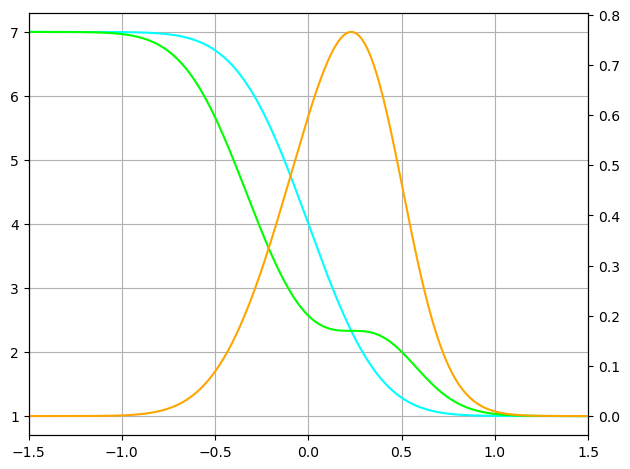

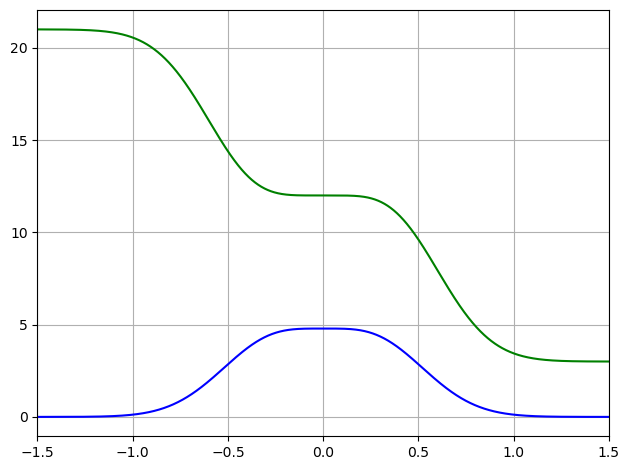

In [61]:
fig, axs = plt.subplots()
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

fig, axs = plt.subplots()
axs.plot(x, u4, label='u4', color='blue')
axs.plot(x, u5, label='u5', color='green')
axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

In [53]:
# Gram Settings
M = 12
closure = "ExtGram"
Kn = 1.0
source_string = "zero_source"#!"relaxation_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [6]:
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

polydeg = 2
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

polydeg = 3
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

/tmp/ipykernel_14235/1137421013.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


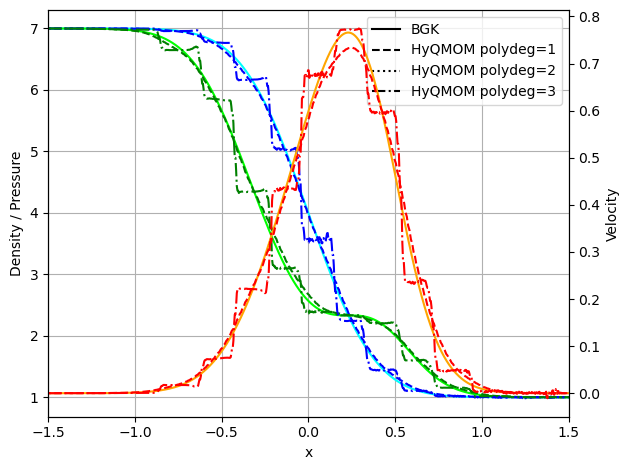

In [11]:
fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM polydeg=2
axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# # HyQMOM polydeg=3
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='HyQMOM polydeg=1')
axs.plot([], [], color='black', linestyle="dotted", label='HyQMOM polydeg=2')
axs.plot([], [], color='black', linestyle="dashdot", label='HyQMOM polydeg=3')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/2202696907.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


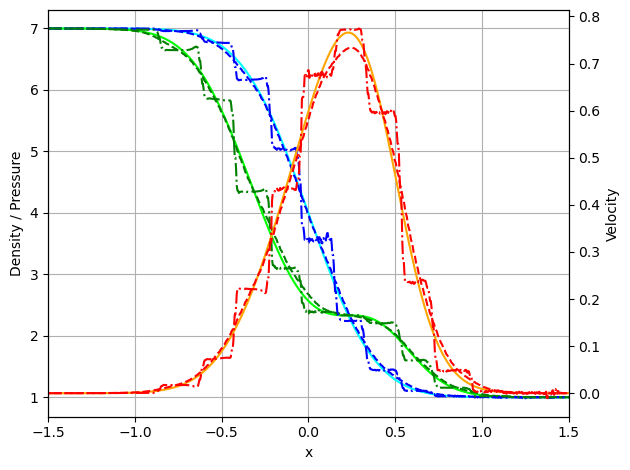

In [16]:
polydeg = 1
base_tree_level = 8
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

polydeg = 3
base_tree_level = 8
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

polydeg = 3
base_tree_level = 6
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM polydeg=2
# axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
# axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
# ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# # HyQMOM polydeg=3
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='HyQMOM polydeg=1, base tree level=8')
axs.plot([], [], color='black', linestyle="dotted", label='HyQMOM polydeg=3, base tree level=8')
axs.plot([], [], color='black', linestyle="dashdot", label='HyQMOM polydeg=3, base tree level=6')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
# axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/414343608.py:52: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


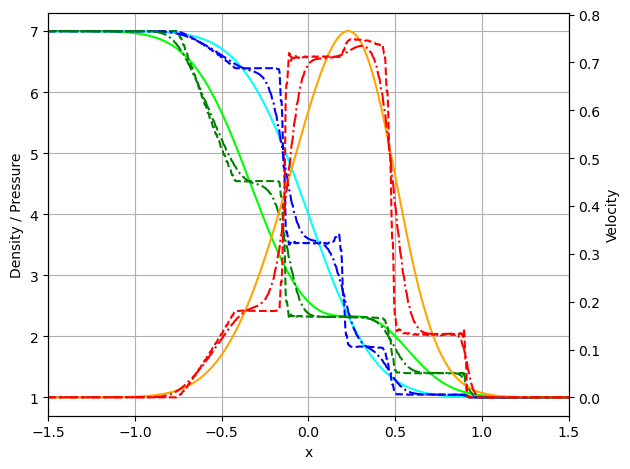

In [24]:
M = 4
polydeg = 3
base_tree_level = 6
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

# polydeg = 3
# base_tree_level = 8
# csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
# df2 = pd.read_csv(csv_file2)

polydeg = 1
base_tree_level = 6
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM polydeg=2
# axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
# axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
# ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# # HyQMOM polydeg=3
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='HyQMOM polydeg=1, base tree level=8')
axs.plot([], [], color='black', linestyle="dotted", label='HyQMOM polydeg=3, base tree level=8')
axs.plot([], [], color='black', linestyle="dashdot", label='HyQMOM polydeg=3, base tree level=6')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
# axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/284695130.py:52: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


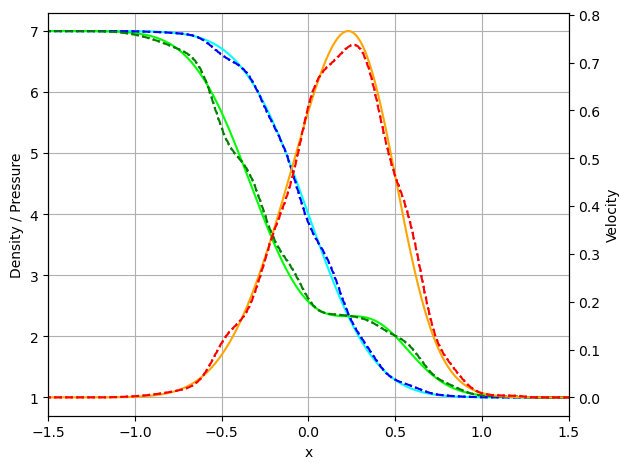

In [29]:
M = 8
polydeg = 1
base_tree_level = 6
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

polydeg = 1
base_tree_level = 8
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

# polydeg = 1
# base_tree_level = 10
# csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
# df3 = pd.read_csv(csv_file3)

fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM polydeg=2
axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# # # HyQMOM polydeg=3
# axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
# axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
# ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='HyQMOM polydeg=1, base tree level=8')
axs.plot([], [], color='black', linestyle="dotted", label='HyQMOM polydeg=3, base tree level=8')
axs.plot([], [], color='black', linestyle="dashdot", label='HyQMOM polydeg=3, base tree level=6')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
# axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/875006521.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


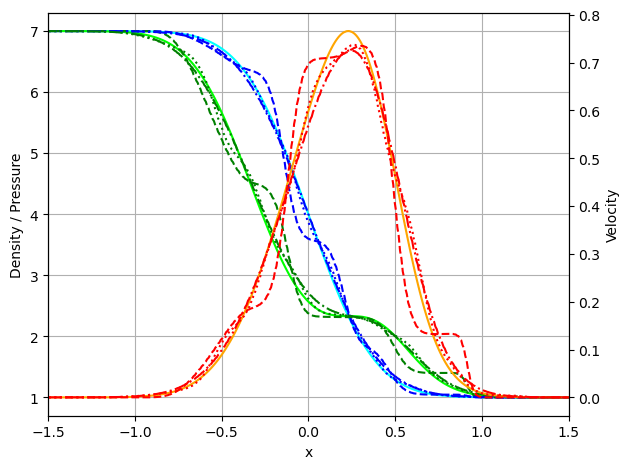

In [59]:
M = 4
polydeg = 1
base_tree_level = 6
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

M = 8
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

M = 24
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM - M=4
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM - M=8
axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# HyQMOM - M=24
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='M=4')
axs.plot([], [], color='black', linestyle="dotted", label='M=8')
axs.plot([], [], color='black', linestyle="dashdot", label='M=24')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
# axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from ipywidgets import interact, FloatSlider

In [82]:
def read_solution_file(filename):
    """
    Reads the Trixi-like solution file into a dict:
    {
        timestep: {
            't': float,
            'x': np.ndarray,
            'w': np.ndarray  # shape (n_points, n_vars)
        },
        ...
    }
    """
    data = {}
    timestep = None
    x_vals = []
    u_vals = []

    with open(filename, "r") as f:
        counter = 0
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith("# timestep"):
                # Save previous timestep if available
                if timestep is not None:
                    data[counter] = {
                        "t": time,
                        "x": np.array(x_vals),
                        "u": np.array(u_vals)
                    }
                    counter += 1
                # Parse new header
                parts = line.replace(",", "").split()
                timestep = int(parts[1].split("=")[-1]) if "timestep=" in line else int(parts[1])
                points = int(parts[2].split("=")[-1])
                time = float(parts[3].split("=")[-1])
                x_vals, u_vals = [], []

            elif not line.startswith("#"):
                vals = list(map(float, line.split()))
                x_vals.append(vals[0])
                u_vals.append(vals[1:])  # w^(0..n)

        # Save last timestep
        if timestep is not None:
            data[counter] = {
                "t": time,
                "x": np.array(x_vals),
                "u": np.array(u_vals)
            }
            counter += 1

    return data

In [83]:
def interpolate_solution(data, time_query, times, timesteps):
    """Linear interpolation in time for all w's"""
    # Clamp outside range
    if time_query <= times.min():
        return data[timesteps[0]]
    if time_query >= times.max():
        return data[timesteps[-1]]

    # indices around query
    idx_right = np.searchsorted(times, time_query)
    idx_left = idx_right - 1
    t0, t1 = times[idx_left], times[idx_right]
    u0, u1 = data[timesteps[idx_left]]["u"], data[timesteps[idx_right]]["u"]
    x0 = data[timesteps[idx_left]]["x"]

    # linear interpolation in time
    alpha = (time_query - t0) / (t1 - t0)
    w_interp = (1 - alpha) * u0 + alpha * u1

    return {"t": time_query, "x": x0, "w": w_interp}

In [87]:
def plot_solution_time(data, time_query, times, timesteps):
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, u, t = sol["x"], sol["u"], sol["t"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    axes[0].plot(x, u[:,0], label="$u^{(0)}$", color='blue')
    axes[0].plot(x, u[:,1], label="$u^{(1)}$", color='orange')
    axes[0].plot(x, u[:,2], label="$v^{(2)}$", color='green')
    axes[0].set_title(f"t={t:.4f}")
    axes[0].set_xlabel("X")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(x, u[:,3], label="$u^{(3)}$", color='purple')
    axes[1].plot(x, u[:,4], label="$u^{(4)}$", color='pink')
    # axes[1].plot(x, w[:,5], label="$w^{(5)}$", color='brown')
    # axes[1].plot(x, w[:,6], label="$w^{(6)}$", color='gray')
    axes[1].set_title("Higher moments")
    axes[1].set_xlabel("X")
    axes[1].grid()
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [88]:
# === Usage Example ===
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

# Interactive slider
interact(
    lambda t: plot_solution_time(data, t, times, timesteps),
    t=FloatSlider(min=times.min(), max=times.max(), step=(times[1]-times[0])/10, value=times.min())
)

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.0015), Output()), _dom_classes=(…

<function __main__.<lambda>(t)>

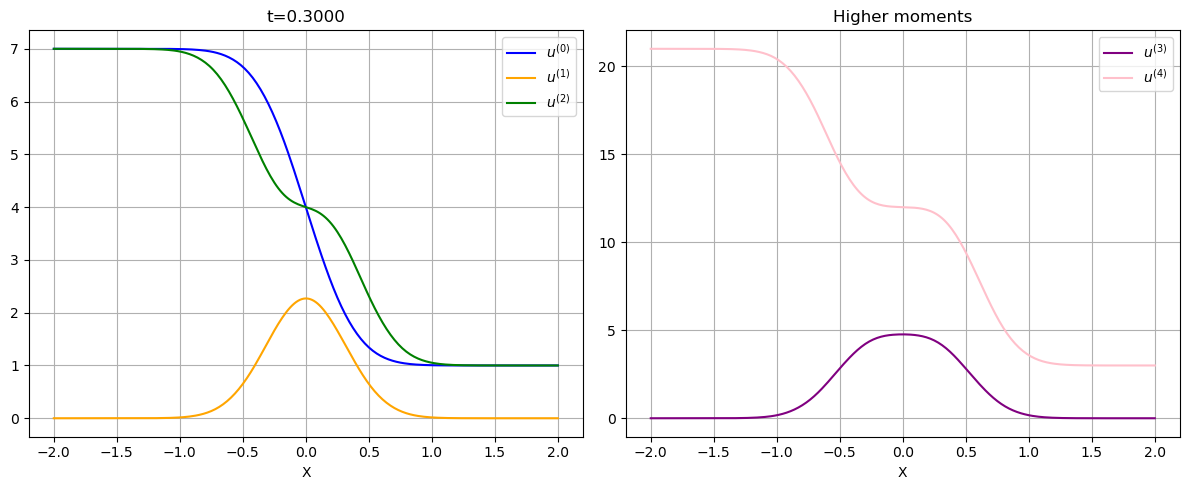

In [89]:
time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(x, u[:,0], label="$u^{(0)}$", color='blue')
axes[0].plot(x, u[:,1], label="$u^{(1)}$", color='orange')
axes[0].plot(x, u[:,2], label="$u^{(2)}$", color='green')
axes[0].set_title(f"t={t:.4f}")
axes[0].set_xlabel("X")
axes[0].grid()
axes[0].legend()

axes[1].plot(x, u[:,3], label="$u^{(3)}$", color='purple')
axes[1].plot(x, u[:,4], label="$u^{(4)}$", color='pink')
axes[1].set_title("Higher moments")
axes[1].set_xlabel("X")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

In [90]:
x_BGK = np.linspace(-6, 6, 10_000)
c_BGK = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, x_BGK, c_BGK[:, None], T)
rho_T = np.trapz(f_T, c_BGK, axis=0)
u_0_BGK = np.trapz(c[:, None]**0 * f_T, c_BGK, axis=0)
v_T = np.trapz(c[:, None] * f_T, c_BGK, axis=0) / rho_T
u_1_BGK = np.trapz(c[:, None]**1 * f_T, c_BGK, axis=0)
theta_T = np.trapz((c[:, None] - v_T)**2 * f_T, c_BGK, axis=0) / rho_T
u_2_BGK = np.trapz(c[:, None]**2 * f_T, c_BGK, axis=0)
p_T = rho_T * theta_T
u_3_BGK = np.trapz(c[:, None]**3 * f_T, c_BGK, axis=0)
u_4_BGK = np.trapz(c[:, None]**4 * f_T, c_BGK, axis=0)

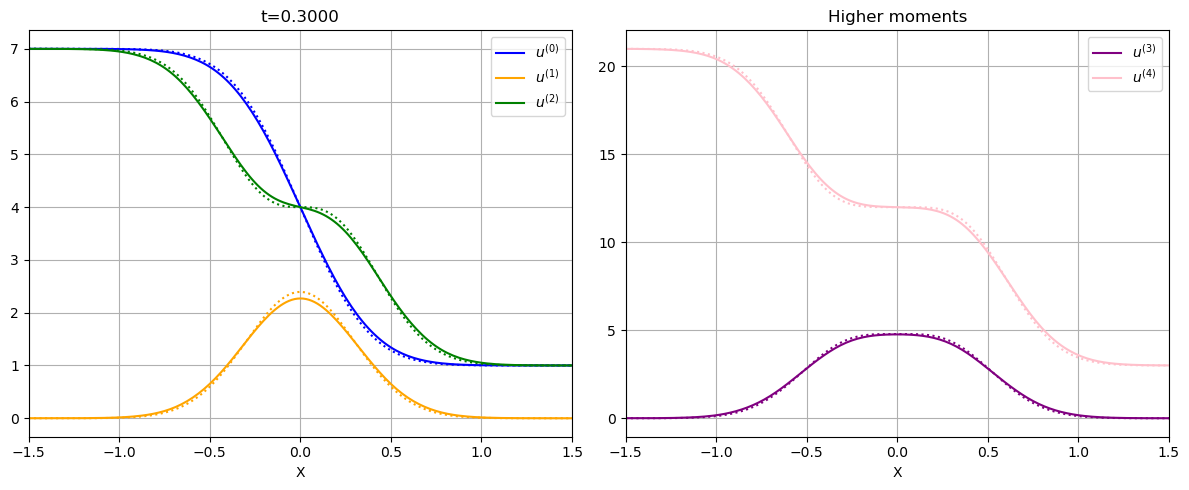

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(x_BGK, u_0_BGK, color='blue', linestyle='dotted')
axes[0].plot(x, u[:,0], label="$u^{(0)}$", color='blue')

axes[0].plot(x_BGK, u_1_BGK, color='orange', linestyle='dotted')
axes[0].plot(x, u[:,1], label="$u^{(1)}$", color='orange')

axes[0].plot(x_BGK, u_2_BGK, color='green', linestyle='dotted')
axes[0].plot(x, u[:,2], label="$u^{(2)}$", color='green')
axes[0].set_title(f"t={t:.4f}")
axes[0].set_xlabel("X")
axes[0].grid()
axes[0].legend()

axes[1].plot(x_BGK, u_3_BGK, color='purple', linestyle='dotted')
axes[1].plot(x, u[:,3], label="$u^{(3)}$", color='purple')

axes[1].plot(x_BGK, u_4_BGK, color='pink', linestyle='dotted')
axes[1].plot(x, u[:,4], label="$u^{(4)}$", color='pink')
axes[1].set_title("Higher moments")
axes[1].set_xlabel("X")
axes[1].grid()
axes[1].legend()

[ax.set_xlim(-1.5, 1.5) for ax in axes]
plt.tight_layout()
plt.show()

In [ ]:
from scipy.interpolate import interp1d

/tmp/ipykernel_14235/1099021597.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


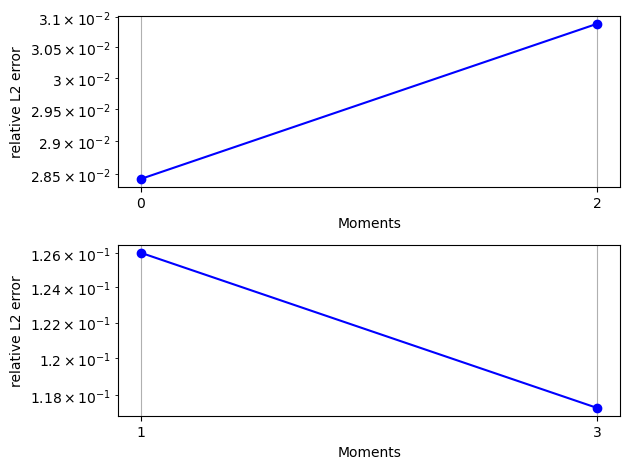

In [129]:
M = 4
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

L2 = []
for i in range(M):
    u_BGK = np.trapz(c[:, None]**i * f_T, c_BGK, axis=0)
    u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
    u_BGK_projected = u_BGK_interp1D(x)
    u_ExtGramian = u[:,i]
    L2.append(
        np.linalg.norm(u_ExtGramian - u_BGK_projected, 2) / np.linalg.norm(u_BGK_projected, 2)
    )
    
moments = np.linspace(0, M-1, M, dtype=int)
fig, axs = plt.subplots(2)
axs[0].semilogy(moments[::2], L2[::2], '-o', color='blue')
axs[0].set_xticks(moments[::2])

axs[1].semilogy(moments[1:][::2], L2[1:][::2], '-o', color='blue')
axs[1].set_xticks(moments[1:][::2])

[ax.grid() for ax in axs]
[ax.set_xlabel('Moments') for ax in axs]
[ax.set_ylabel('relative L2 error') for ax in axs]

fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/3053799665.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


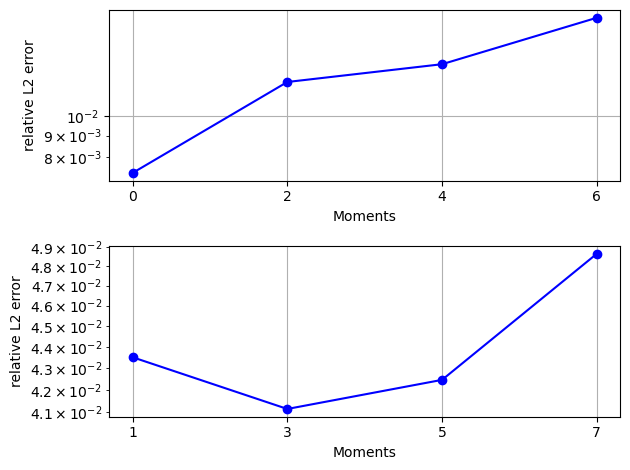

In [130]:
M = 8
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

L2 = []
for i in range(M):
    u_BGK = np.trapz(c[:, None]**i * f_T, c_BGK, axis=0)
    u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
    u_BGK_projected = u_BGK_interp1D(x)
    u_ExtGramian = u[:,i]
    L2.append(
        np.linalg.norm(u_ExtGramian - u_BGK_projected, 2) / np.linalg.norm(u_BGK_projected, 2)
    )
    
moments = np.linspace(0, M-1, M, dtype=int)
fig, axs = plt.subplots(2)
axs[0].semilogy(moments[::2], L2[::2], '-o', color='blue')
axs[0].set_xticks(moments[::2])

axs[1].semilogy(moments[1:][::2], L2[1:][::2], '-o', color='blue')
axs[1].set_xticks(moments[1:][::2])

[ax.grid() for ax in axs]
[ax.set_xlabel('Moments') for ax in axs]
[ax.set_ylabel('relative L2 error') for ax in axs]

fig.tight_layout()
fig.show()

/tmp/ipykernel_14235/4090263734.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


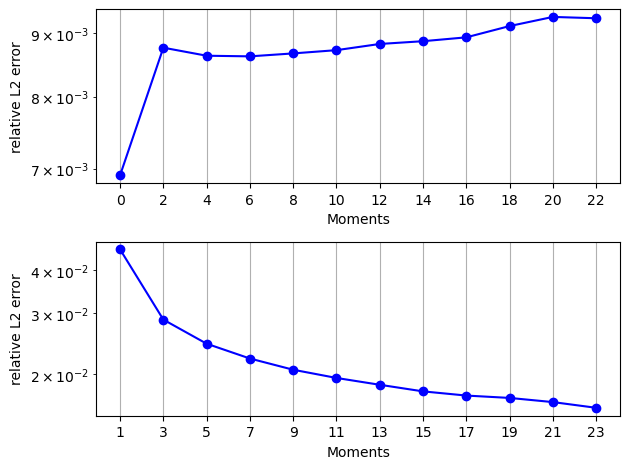

In [131]:
M = 24
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

L2 = []
for i in range(M):
    u_BGK = np.trapz(c[:, None]**i * f_T, c_BGK, axis=0)
    u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
    u_BGK_projected = u_BGK_interp1D(x)
    u_ExtGramian = u[:,i]
    L2.append(
        np.linalg.norm(u_ExtGramian - u_BGK_projected, 2) / np.linalg.norm(u_BGK_projected, 2)
    )
    
moments = np.linspace(0, M-1, M, dtype=int)
fig, axs = plt.subplots(2)
axs[0].semilogy(moments[::2], L2[::2], '-o', color='blue')
axs[0].set_xticks(moments[::2])

axs[1].semilogy(moments[1:][::2], L2[1:][::2], '-o', color='blue')
axs[1].set_xticks(moments[1:][::2])

[ax.grid() for ax in axs]
[ax.set_xlabel('Moments') for ax in axs]
[ax.set_ylabel('relative L2 error') for ax in axs]

fig.tight_layout()
fig.show()